In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage




In [7]:
data_path = "../data/heart_disease_selected.csv"
df = pd.read_csv(data_path)

X = df.drop(columns=["target"])
y = df["target"]

In [8]:
if set(y.unique()) <= {0,1}:
    y = y.astype(int)
elif set(y.unique()) <= {-1,0}:
    y = y.replace(-1,1).astype(int)
else:
    y = (y > 0).astype(int)

# K-means


In [9]:
inertia = []
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

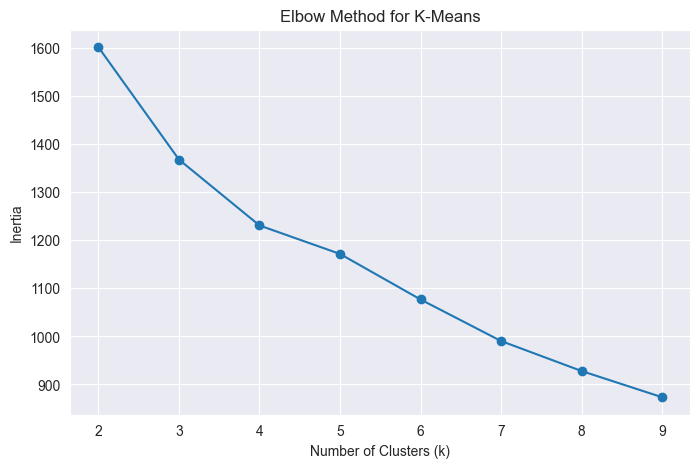

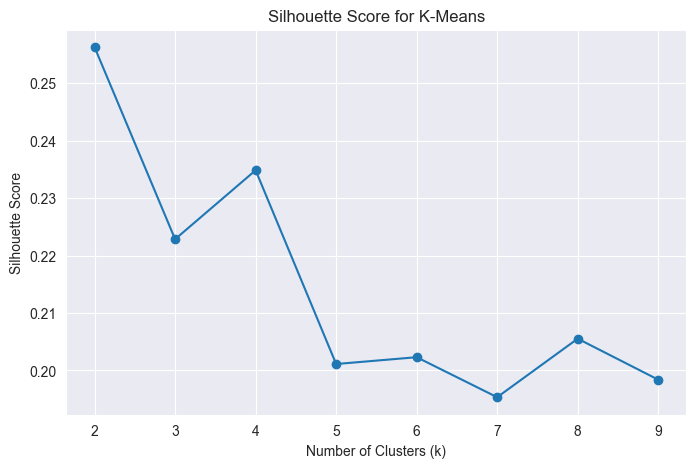

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), inertia, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouette_scores, marker="o")
plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_kmeans = kmeans.fit_predict(X)

ari_kmeans = adjusted_rand_score(y, clusters_kmeans)
print(ari_kmeans)

0.2284859223071275


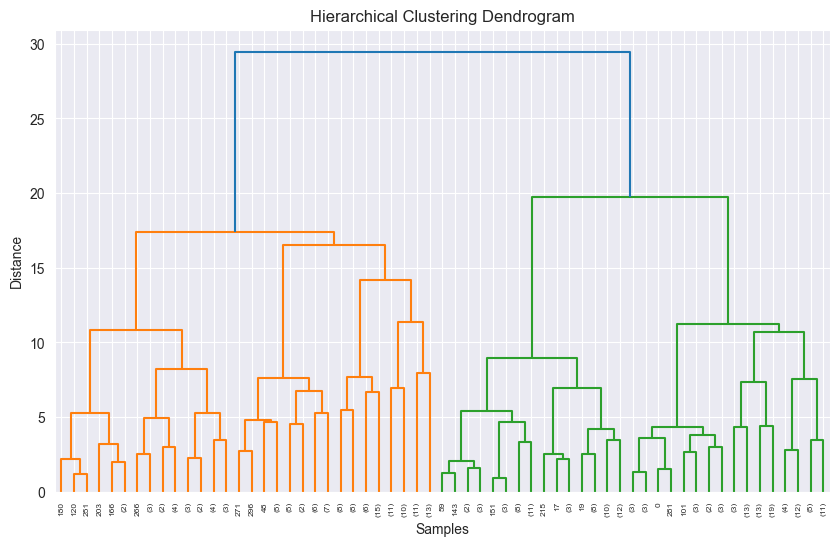

0.2782907570779415


In [14]:
plt.figure(figsize=(10, 6))
linked = linkage(X, method="ward")
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

hier = AgglomerativeClustering(n_clusters=2)
clusters_hier = hier.fit_predict(X)

ari_hier = adjusted_rand_score(y, clusters_hier)
print(ari_hier)

In [15]:
results = pd.DataFrame({
    "True_Label": y,
    "KMeans_Cluster": clusters_kmeans,
    "Hierarchical_Cluster": clusters_hier
})

results.to_csv("../results/clustering_results.csv", index=False)